In [26]:
# Imports
import pandas as pd
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import os
from joblib import dump, load
from collections import Counter
import warnings

# Métricas e ferramentas de Machine Learning
from imblearn.over_sampling import SMOTE
from sklearn import preprocessing
from scipy.spatial.distance import cdist
from cuml.ensemble import RandomForestClassifier as CuMLRF
from sklearn.ensemble import RandomForestClassifier as SkRF
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix)
import shap

dados = pd.read_csv ("../Databases/base_treino_boruta.csv", sep=',')
dados

,sample_id,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,GSM2278615,1.030720,1.152392,-0.321811,-0.388305,-0.632559,-0.006389,-0.173028,0.734924,-0.538253,...,0.558312,0.682544,-0.281433,-0.152731,-0.136623,0.091852,-0.503763,1.053621,1,train
1,GSM2278616,1.773204,0.953377,-0.173949,-0.473914,-0.558560,0.032618,0.436156,0.842601,-0.515910,...,2.327494,0.270474,-1.432550,0.126085,1.908569,-0.476252,-0.810687,0.903694,1,train
2,GSM2278617,0.684740,0.403192,-0.496596,-0.608497,-0.066235,-1.190762,2.336523,0.121293,-0.042676,...,0.379008,0.212516,-0.912393,2.028289,-0.133262,-1.409829,-0.114039,0.013329,1,train
3,GSM2278618,-0.794088,-1.039456,-0.325646,-0.392525,-0.382181,-0.085807,0.056988,1.684487,-0.236236,...,1.159776,-0.186710,-1.223107,0.149769,-0.128983,-1.642710,0.321930,0.527365,1,train
4,GSM2278619,-1.453257,-0.910481,-0.491062,-0.424341,-0.479572,-0.036304,0.178505,0.631550,-0.728127,...,-0.839302,-0.348432,-0.809020,0.294022,0.486672,-1.282433,-1.035871,0.367641,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,GSM1447837,1.328089,0.849867,1.410876,2.054690,1.477953,1.944974,-0.440131,-0.042935,-0.007901,...,-0.860789,-0.101230,0.246102,-0.030673,-1.283171,1.365195,0.346937,-0.132385,0,train
281,GSM1447839,-1.429717,-1.267393,1.671507,2.089174,1.935565,-0.035735,0.167215,-0.624830,0.249774,...,-1.316962,1.582785,1.226486,-3.219079,-1.514643,2.006021,1.122274,-2.233914,0,train
282,GSM1447840,-0.345422,-0.366692,1.147987,1.722085,1.612545,0.596328,-0.269979,-1.103681,0.572284,...,-0.574166,-0.939608,2.324517,-1.450733,-0.072031,0.567534,1.845342,-0.367161,0,train
283,GSM1447841,-0.365179,-1.267393,0.078382,1.693163,1.418407,0.877449,-1.697361,-0.624830,0.445940,...,0.511769,-0.565786,0.997730,-1.529889,0.126708,0.120642,1.411211,1.093030,0,train


In [27]:
# normalizar
# remover colunas que não são features
dados_num = dados.drop(columns=["sample_id", "target", "split"])

# target (0/1) separado como categorico
dados_cat = dados[["target"]]

# Instanciar o objeto normalizador
normalizador = preprocessing.MinMaxScaler()

# treinar o normalizador apenas nas features
modelo_normalizador_num = normalizador.fit(dados_num)

# salvando modelo normalizador
dump(modelo_normalizador_num, open("models_Tree_GPU/normalizador_GPU.model","wb"))

# normalizar atributos numéricos
dados_num_normalizado = modelo_normalizador_num.transform(dados_num)

# converter de volta para DataFrame
dados_num_df = pd.DataFrame(dados_num_normalizado, columns=dados_num.columns)

# juntar target (0/1) e split
dados_final = dados_num_df.join(dados_cat).join(dados[["split"]])
dados_final

,MIMAT0000070,MIMAT0000103,MIMAT0003240,MIMAT0004592,MIMAT0004602,MIMAT0004804,MIMAT0005586,MIMAT0007347,MIMAT0016849,MIMAT0018192,...,MIMAT0027478,MIMAT0027498,MIMAT0027540,MIMAT0027574,MIMAT0027575,MIMAT0027660,MIMAT0027686,MIMAT0031000,target,split
0,0.642643,0.556037,0.507214,0.198630,0.352515,0.568801,0.397176,0.449194,0.413662,0.444543,...,0.624663,0.630741,0.442053,0.527822,0.615689,0.483571,0.342527,0.473657,1,train
1,0.773114,0.515801,0.533194,0.175908,0.368558,0.574554,0.508098,0.465468,0.418135,0.570501,...,0.934508,0.569896,0.242716,0.575816,0.936687,0.406730,0.288510,0.452056,1,train
2,0.581846,0.404566,0.476502,0.140186,0.475293,0.394103,0.854120,0.356452,0.512861,0.398060,...,0.593260,0.561338,0.332790,0.903250,0.616216,0.280456,0.411117,0.323775,1,train
3,0.321981,0.112897,0.506540,0.197510,0.406797,0.557086,0.439058,0.592709,0.474116,0.511615,...,0.730000,0.502390,0.278985,0.579893,0.616888,0.248957,0.487846,0.397836,1,train
4,0.206149,0.138973,0.477475,0.189066,0.385683,0.564388,0.461184,0.433571,0.375656,0.608076,...,0.379892,0.478510,0.350691,0.604724,0.713517,0.297687,0.248878,0.374823,1,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,0.694897,0.494874,0.811663,0.847058,0.810070,0.856631,0.348542,0.331630,0.519822,0.579420,...,0.376128,0.515011,0.533405,0.548833,0.435735,0.655801,0.492248,0.302781,0,train
281,0.210286,0.066814,0.857459,0.856211,0.909279,0.564472,0.459128,0.243684,0.571400,0.609914,...,0.296237,0.763669,0.703176,0.000000,0.399405,0.742478,0.628704,0.000000,0,train
282,0.400822,0.248914,0.765471,0.758777,0.839249,0.657703,0.379523,0.171312,0.635956,0.782556,...,0.426326,0.391219,0.893320,0.304392,0.625827,0.547911,0.755962,0.268956,0,train
283,0.397350,0.066814,0.577531,0.751101,0.797160,0.699169,0.119623,0.243684,0.610666,1.000000,...,0.616511,0.446416,0.663563,0.290767,0.657019,0.487465,0.679556,0.479335,0,train


In [28]:
# separar target e atributos
dados_classes = dados_final[['target']]
dados_atributos = dados_final.drop(columns=['target', 'split'])

# preencher NaNs numericos com media (so um seguro)
dados_atributos = dados_atributos.fillna(dados_atributos.mean())

# converter target para array binario (0/1)
dados_classes_bin = dados_classes['target'].values

resampler = SMOTE(random_state=42)

dados_atributos_b, dados_classes_b = resampler.fit_resample(dados_atributos,dados_classes_bin)

# frequência apos balanceamento
print('------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------')
print(Counter(dados_classes_b))

------ FREQUÊNCIA DAS CLASSES APÓS O BALANCEAMENTO ------
Counter({1: 150, 0: 150})


In [29]:
X = dados_atributos_b.values.astype(np.float32)
y = dados_classes_b.astype(np.int32)

feature_names = dados_atributos.columns

print("\nTreinando RandomForest GPU...")

rf = CuMLRF(n_estimators=1000,max_depth=60,max_features="sqrt",min_samples_leaf=2,n_bins=64,n_streams=1,random_state=42)

rf.fit(X,y)

print("Treino finalizado!")

os.makedirs("models_Tree_GPU",exist_ok=True)

dump(rf,"models_Tree_GPU/modelo_RF_GPU.joblib")

dados_teste = pd.read_csv("../Databases/base_teste_boruta.csv")

X_test_df = dados_teste.drop(columns=["sample_id","target","split"])

y_test = dados_teste["target"].values

X_test_df = X_test_df.fillna(X_test_df.mean())

X_test_df = X_test_df.reindex(columns=feature_names,fill_value=0)

X_test = X_test_df.values.astype(np.float32)

y_pred = np.array(rf.predict(X_test))

y_prob = rf.predict_proba(X_test)[:,1]

print("\n===== MÉTRICAS NO TESTE =====")

print("Accuracy :",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall   :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))
print("ROC AUC  :",roc_auc_score(y_test,y_prob))

print("\nClassification Report:")
print(classification_report(y_test,y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))

print("\nCalculando Permutation Importance...")

perm = permutation_importance(rf,X_test,y_test,n_repeats=5,random_state=42,n_jobs=-1)

perm_df = pd.Series(perm.importances_mean,index=feature_names).sort_values(ascending=False)

print("\nTop 20 (Permutation Importance)")
print(perm_df.head(20))

print("\nCalculando SHAP...")

rf_shap = SkRF(n_estimators=200,max_depth=20,random_state=42,n_jobs=-1)

rf_shap.fit(X,y)

explainer = shap.TreeExplainer(rf_shap)

X_shap = pd.DataFrame(X_test,columns=feature_names)

X_shap_sample = X_shap.sample(min(300,len(X_shap)),random_state=42)

shap_values = explainer.shap_values(X_shap_sample)

sv = np.array(shap_values)

if sv.ndim==3:
    sv = sv[:,:,1]

shap_importance = np.mean(np.abs(sv),axis=0)

shap_df = pd.Series(shap_importance,index=feature_names).sort_values(ascending=False)

shap_results = {"global":shap_df}

print("\nTop 20 (SHAP)")
print(shap_df.head(20))

shap_df.to_csv("models_Tree_GPU/shap_importance.csv")

resultados = pd.DataFrame({"Real":y_test,"Predito":y_pred,"Probabilidade":y_prob})

print("\n===== INFERÊNCIA COMPLETA =====")

print(resultados.head(10))

print("\nDistribuição de classes previstas:")
print(resultados["Predito"].value_counts())

rf=None


Treinando RandomForest GPU...
Treino finalizado!

===== MÉTRICAS NO TESTE =====
Accuracy : 0.9305555555555556
Precision: 0.8837209302325582
Recall   : 1.0
F1 Score : 0.9382716049382717
ROC AUC  : 0.9860681114551083

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        34
           1       0.88      1.00      0.94        38

    accuracy                           0.93        72
   macro avg       0.94      0.93      0.93        72
weighted avg       0.94      0.93      0.93        72


Confusion Matrix:
[[29  5]
 [ 0 38]]

Calculando Permutation Importance...

Top 20 (Permutation Importance)
MIMAT0023700    1.388890e-02
MIMAT0004602    5.555582e-03
MIMAT0027686    2.777791e-03
MIMAT0004804    2.777791e-03
MIMAT0004592    1.192093e-08
MIMAT0000070    0.000000e+00
MIMAT0027359    0.000000e+00
MIMAT0022945    0.000000e+00
MIMAT0024598    0.000000e+00
MIMAT0026720    0.000000e+00
MIMAT0027574    0.000000e+00
MIMAT


Gerando gráficos de interpretabilidade...
Figura salva: plots/Permutation_Top20.png


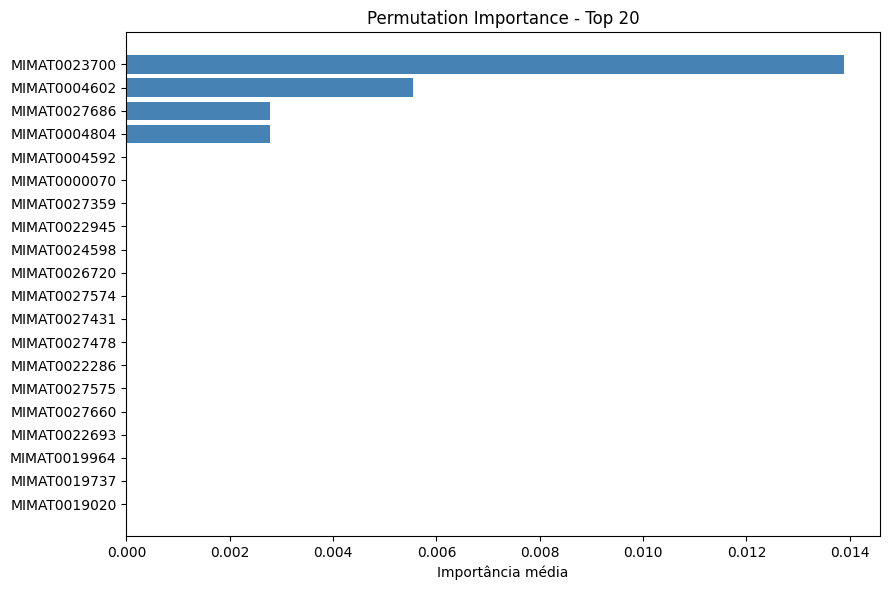

Figura salva: plots/SHAP_Top20.png


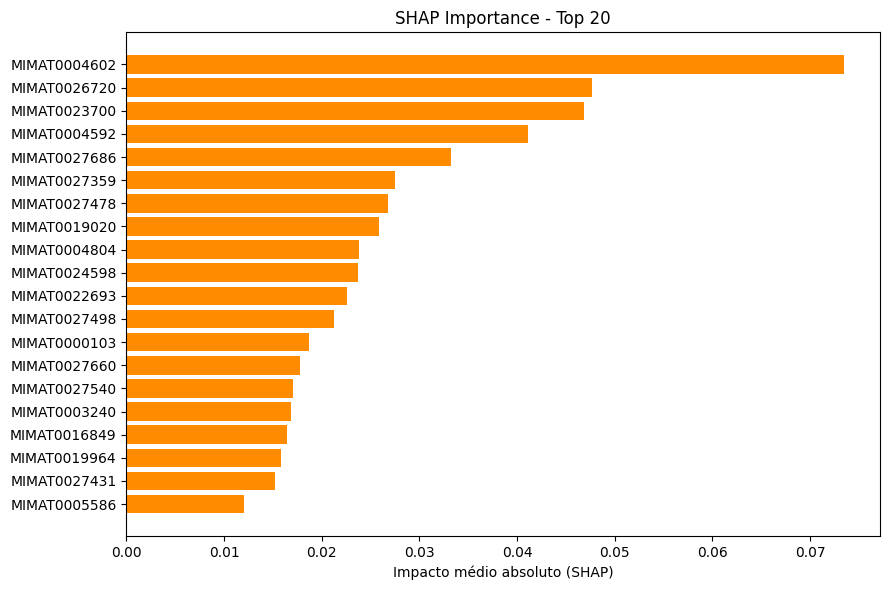


Correlação SHAP vs Permutation Importance: 0.7973


In [34]:
top_k = 20

print("\nGerando gráficos de interpretabilidade...")

perm_top = perm_df.head(top_k).iloc[::-1]
shap_top = shap_df.head(top_k).iloc[::-1]

fig, ax = plt.subplots(figsize=(9,6))
ax.barh(perm_top.index, perm_top.values,color="steelblue")
ax.set_title(f"Permutation Importance - Top {top_k}")
ax.set_xlabel("Importância média")
plt.tight_layout()
out_path = os.path.join("plots", f"Permutation_Top{top_k}.png")
fig.savefig(out_path,dpi=300,bbox_inches="tight")
print(f"Figura salva: {out_path}")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9,6))
ax.barh(shap_top.index, shap_top.values,color="darkorange")
ax.set_title(f"SHAP Importance - Top {top_k}")
ax.set_xlabel("Impacto médio absoluto (SHAP)")
plt.tight_layout()
out_path = os.path.join("plots", f"SHAP_Top{top_k}.png")
fig.savefig(out_path,dpi=300,bbox_inches="tight")
print(f"Figura salva: {out_path}")
plt.show()
plt.close(fig)

corr = np.corrcoef(perm_df.values, shap_df.values)[0,1]
print(f"\nCorrelação SHAP vs Permutation Importance: {corr:.4f}")

In [33]:
rf = load("models_Tree_GPU/modelo_RF_GPU.joblib")
print("\n---- INFERÊNCIA FINAL (BASE DE TESTE) ----")

# garantir mesma ordem de colunas usada no treino
X_infer_df = dados_teste.drop(columns=["sample_id","target","split"])
X_infer_df = X_infer_df.fillna(X_infer_df.mean())
X_infer_df = X_infer_df.reindex(columns=feature_names,fill_value=0)

X_infer = X_infer_df.values.astype(np.float32)

# predição
y_pred_infer = np.array(rf.predict(X_infer))
y_prob_infer = rf.predict_proba(X_infer)[:,1]

# resultado estruturado
df_infer = pd.DataFrame({
    "Real": dados_teste["target"].values,
    "Predito": y_pred_infer,
    "Probabilidade_PDAC": y_prob_infer
})

print(df_infer.head(15))

# distribuição
print("\nDistribuição de predições:")
print(df_infer["Predito"].value_counts())

# análise de confiança
print("\nResumo de probabilidades:")
print(df_infer["Probabilidade_PDAC"].describe())

# casos mais confiantes de PDAC
print("\nTop 10 mais prováveis PDAC:")
print(df_infer.sort_values("Probabilidade_PDAC", ascending=False).head(10))

# casos mais confiantes de controle
print("\nTop 10 mais prováveis Controle:")
print(df_infer.sort_values("Probabilidade_PDAC").head(10))


---- INFERÊNCIA FINAL (BASE DE TESTE) ----
    Real  Predito  Probabilidade_PDAC
0      1      1.0            0.556050
1      1      1.0            0.554867
2      1      1.0            0.618333
3      1      1.0            0.658633
4      1      1.0            0.745833
5      1      1.0            0.741750
6      1      1.0            0.692250
7      1      1.0            0.589733
8      1      1.0            0.642067
9      1      1.0            0.632483
10     1      1.0            0.633083
11     1      1.0            0.570617
12     1      1.0            0.686850
13     1      1.0            0.749250
14     1      1.0            0.584233

Distribuição de predições:
1.0    43
0.0    29
Name: Predito, dtype: int64

Resumo de probabilidades:
count    72.000000
mean      0.495248
std       0.244284
min       0.035200
25%       0.234279
50%       0.564325
75%       0.693354
max       0.881250
Name: Probabilidade_PDAC, dtype: float64

Top 10 mais prováveis PDAC:
    Real  Predito  Prob